# BigMart Sales Prediction

![](https://www.analyticsvidhya.com/wp-content/uploads/2016/02/Comp-4.jpg)

## Objective

The data scientists at BigMart have collected sales data for 1559 products across 10 stores in different cities. Also, certain attributes of each product and store have been defined. The aim is to build a predictive model and find out the sales of each product at a particular store (each row of data).

__So the idea is to find out the features (properties) of a product, and store which impacts the sales of a product.__






## Dataset Details

![](https://i.imgur.com/WlgNuFs.png)

## Get the Dataset

You can download the dataset manually from [this link](https://drive.google.com/file/d/1xFDvCOLa_gu34CosX8kSCIqqhD-E2te8/view?usp=sharing) or use the following code snippet to load in in google colab directly.

In [4]:
!gdown --id 1xFDvCOLa_gu34CosX8kSCIqqhD-E2te8

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1xFDvCOLa_gu34CosX8kSCIqqhD-E2te8
To: /content/sales_prediction.csv
100% 870k/870k [00:00<00:00, 77.5MB/s]


# Load Dataset

In [5]:
import pandas as pd

df=pd.read_csv('sales_prediction.csv')

In [6]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


# Prepare and Training Dataset

In [7]:
x=df.drop(columns='Item_Outlet_Sales')
y=df['Item_Outlet_Sales']

SEED=42

In [8]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.3, random_state=SEED)

x_train.shape, x_test.shape

((5966, 11), (2557, 11))

In [9]:
x_train.head(3)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
1921,FDN08,7.72,Regular,0.147904,Fruits and Vegetables,116.6466,OUT010,1998,NaN,Tier 3,Grocery Store
655,NCJ42,19.75,Low Fat,0.014301,Household,103.0332,OUT046,1997,Small,Tier 1,Supermarket Type1
2229,FDY47,NaN,Regular,0.054221,Breads,129.1310,OUT027,1985,Medium,Tier 3,Supermarket Type3


In [10]:
y_train.head(3)

,Item_Outlet_Sales
1921,117.8466
655,1230.3984
2229,4933.5780


# Data Wrangling, EDA and Feature Extraction

In [11]:
#make copy of training data
x_train_c=x_train.copy()

In [12]:
x_train_c.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5966 entries, 1921 to 7270
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            5966 non-null   object 
 1   Item_Weight                4943 non-null   float64
 2   Item_Fat_Content           5966 non-null   object 
 3   Item_Visibility            5966 non-null   float64
 4   Item_Type                  5966 non-null   object 
 5   Item_MRP                   5966 non-null   float64
 6   Outlet_Identifier          5966 non-null   object 
 7   Outlet_Establishment_Year  5966 non-null   int64  
 8   Outlet_Size                4276 non-null   object 
 9   Outlet_Location_Type       5966 non-null   object 
 10  Outlet_Type                5966 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 559.3+ KB


In [13]:
x_train_c.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1023
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,1690
Outlet_Location_Type,0


In [14]:
num_data=x_train_c.select_dtypes(exclude=['object'])
num_data.head()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year
1921,7.72,0.147904,116.6466,1998
655,19.75,0.014301,103.0332,1997
2229,NaN,0.054221,129.1310,1985
2537,19.35,0.118342,222.6088,2002
3528,18.35,0.092150,184.8266,1987


In [15]:
num_data.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year
count,4943.000000,5966.000000,5966.000000,5966.000000
mean,12.937193,0.065821,141.814242,1997.867248
std,4.630433,0.051093,62.627609,8.385023
min,4.555000,0.000000,31.290000,1985.000000
25%,8.895000,0.026982,94.144250,1987.000000
50%,12.650000,0.053923,143.879900,1999.000000
75%,17.000000,0.094350,186.621400,2004.000000
max,21.350000,0.328391,266.888400,2009.000000


In [16]:
num_data.isnull().sum()

,0
Item_Weight,1023
Item_Visibility,0
Item_MRP,0
Outlet_Establishment_Year,0


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: ylabel='Item_Weight'>

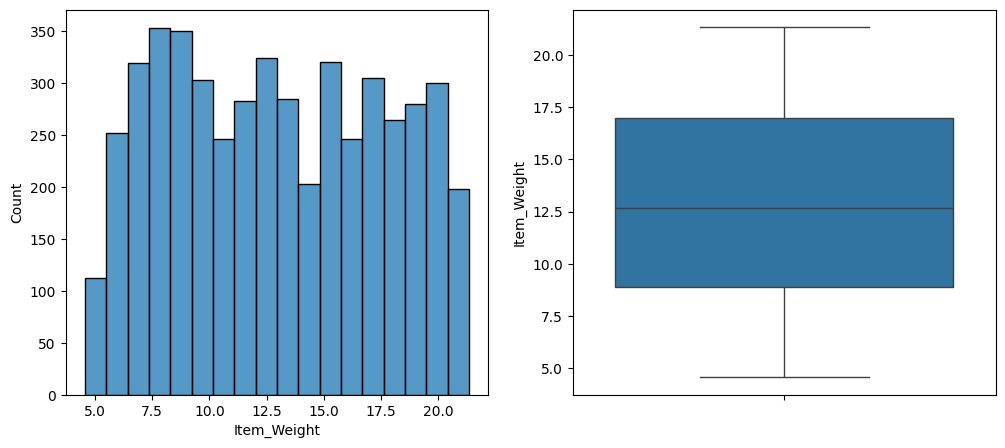

In [18]:
fig,ax = plt.subplots(1,2, figsize=(12,5))

sns.histplot(data=x_train_c, x='Item_Weight', ax=ax[0])
sns.boxplot(data=x_train_c, y='Item_Weight',ax=ax[1])

In [19]:
def visualize_numeric_feature(data_frame, col_name):
  fig,ax = plt.subplots(1,2, figsize=(12,5))
  sns.histplot(data=data_frame, x=col_name, ax=ax[0])
  sns.boxplot(data=data_frame, y=col_name,ax=ax[1])

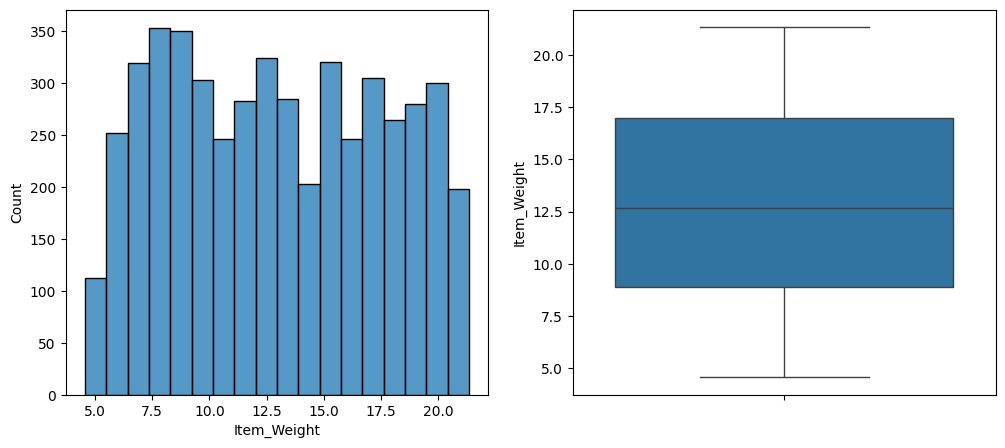

In [20]:
visualize_numeric_feature(x_train_c, 'Item_Weight')

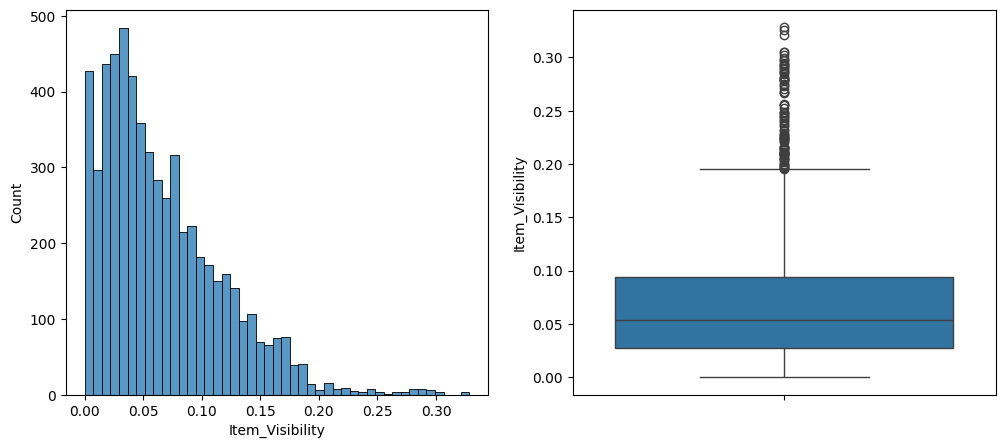

In [21]:
visualize_numeric_feature(x_train_c, 'Item_Visibility')

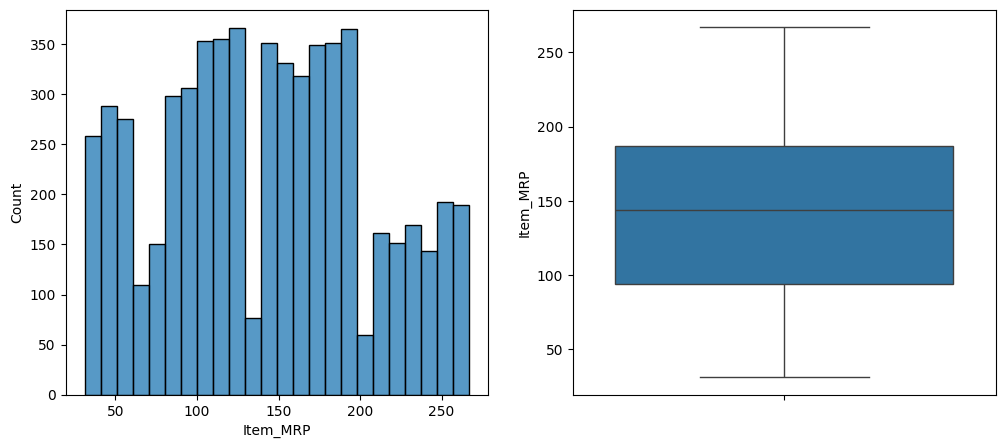

In [22]:
visualize_numeric_feature(x_train_c, 'Item_MRP')

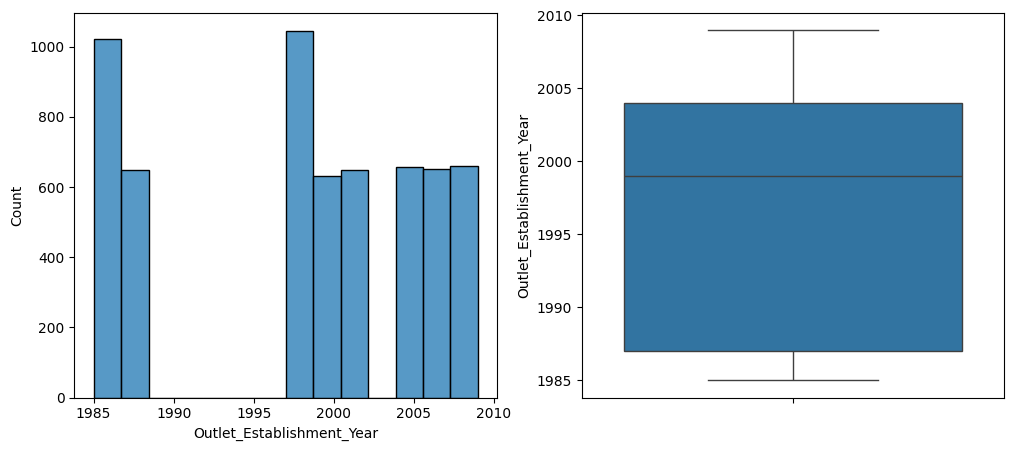

In [23]:
visualize_numeric_feature(x_train_c, 'Outlet_Establishment_Year')

<Axes: xlabel='Outlet_Establishment_Year', ylabel='count'>

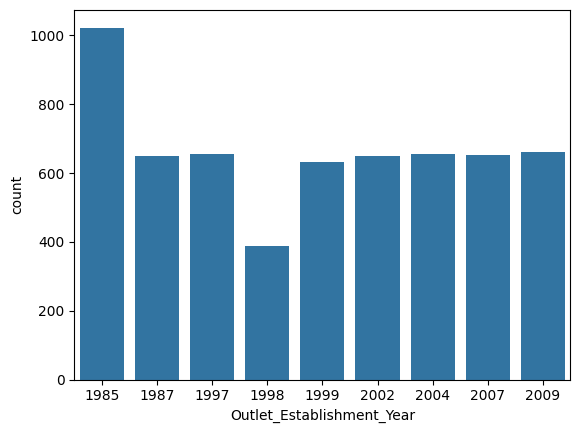

In [24]:
sns.countplot(data=x_train_c,x='Outlet_Establishment_Year')

In [25]:
cat_features= x_train_c.select_dtypes(include=['object'])
cat_features.head()

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
1921,FDN08,Regular,Fruits and Vegetables,OUT010,NaN,Tier 3,Grocery Store
655,NCJ42,Low Fat,Household,OUT046,Small,Tier 1,Supermarket Type1
2229,FDY47,Regular,Breads,OUT027,Medium,Tier 3,Supermarket Type3
2537,FDN45,Low Fat,Snack Foods,OUT045,NaN,Tier 2,Supermarket Type1
3528,FDY16,Regular,Frozen Foods,OUT013,High,Tier 3,Supermarket Type1


In [26]:
cat_features.describe()

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
count,5966,5966,5966,5966,4276,5966,5966
unique,1543,5,16,10,3,3,4
top,FDF52,Low Fat,Fruits and Vegetables,OUT027,Medium,Tier 3,Supermarket Type1
freq,9,3535,905,668,1960,2367,3893


In [27]:
cat_features.isnull().sum()

,0
Item_Identifier,0
Item_Fat_Content,0
Item_Type,0
Outlet_Identifier,0
Outlet_Size,1690
Outlet_Location_Type,0
Outlet_Type,0


In [28]:
cat_features['Item_Identifier'].value_counts()

,count
Item_Identifier,
FDF52,9
NCI54,9
FDN56,8
DRE49,8
FDV60,8
...,...
FDR16,1
FDY19,1
FDV27,1


In [29]:
cat_features['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,3535
Regular,2027
LF,243
low fat,82
reg,79


In [30]:
cat_features['Item_Type'].value_counts()

,count
Item_Type,
Fruits and Vegetables,905
Snack Foods,835
Household,648
Frozen Foods,591
Dairy,474
Canned,450
Baking Goods,438
Health and Hygiene,365
Soft Drinks,305


In [31]:
cat_features['Outlet_Identifier'].value_counts()

,count
Outlet_Identifier,
OUT027,668
OUT018,661
OUT035,656
OUT046,656
OUT017,652
OUT013,649
OUT045,649
OUT049,631
OUT010,389


In [32]:
cat_features['Outlet_Location_Type'].value_counts()

,count
Outlet_Location_Type,
Tier 3,2367
Tier 2,1957
Tier 1,1642


In [33]:
cat_features['Outlet_Type'].value_counts()

,count
Outlet_Type,
Supermarket Type1,3893
Grocery Store,744
Supermarket Type3,668
Supermarket Type2,661


# Data Wrangling + Feature Engineering

#Step 1: Create High Level Item Types

In [34]:
x_train_c['Item_Identifier'].apply(lambda x:x [:2])

,Item_Identifier
1921,FD
655,NC
2229,FD
2537,FD
3528,FD
...,...
5734,FD
5191,FD
5390,NC
860,FD


In [35]:
x_train_c['Item_Identifier'].apply(lambda x:x [:2]).value_counts()

,count
Item_Identifier,
FD,4269
NC,1137
DR,560


In [36]:
x_train_c['Item_Identifier'].str[:2].value_counts()

,count
Item_Identifier,
FD,4269
NC,1137
DR,560


In [37]:
def create_item_type(data_frame):
  data_frame['Item_Type']= data_frame['Item_Identifier'].str[:2]
  data_frame['Item_Type']= data_frame['Item_Type'].map({
                                            'FD' : 'Food',
                                            'NC' : 'Non_Consumables',
                                            'DR' : 'Drink'
  })
  return data_frame


In [38]:
x_train_c=create_item_type(x_train_c)
x_train_c.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
1921,FDN08,7.72,Regular,0.147904,Food,116.6466,OUT010,1998,NaN,Tier 3,Grocery Store
655,NCJ42,19.75,Low Fat,0.014301,Non_Consumables,103.0332,OUT046,1997,Small,Tier 1,Supermarket Type1
2229,FDY47,NaN,Regular,0.054221,Food,129.1310,OUT027,1985,Medium,Tier 3,Supermarket Type3
2537,FDN45,19.35,Low Fat,0.118342,Food,222.6088,OUT045,2002,NaN,Tier 2,Supermarket Type1
3528,FDY16,18.35,Regular,0.092150,Food,184.8266,OUT013,1987,High,Tier 3,Supermarket Type1


# Step 2: Fill in Missing Values for Item_Weight

In [39]:
x_train_c.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1023
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,1690
Outlet_Location_Type,0


In [40]:
x_train_c [['Item_Identifier', 'Item_Weight']].drop_duplicates().sort_values(by=['Item_Identifier'])

,Item_Identifier,Item_Weight
1245,DRA12,11.60
4900,DRA24,19.35
6057,DRA59,NaN
1876,DRA59,8.27
3733,DRB01,NaN
...,...,...
411,NCZ42,10.50
2084,NCZ53,NaN
6879,NCZ53,9.60
7926,NCZ54,14.65


In [42]:
x_train_c [['Item_Type', 'Item_Weight']].drop_duplicates().sort_values(by=['Item_Type'])

,Item_Type,Item_Weight
2796,Drink,5.730
998,Drink,20.250
670,Drink,8.395
6091,Drink,13.500
3438,Drink,13.850
...,...,...
6624,Non_Consumables,12.600
6191,Non_Consumables,8.880
1911,Non_Consumables,19.850
135,Non_Consumables,7.235


In [45]:
ITEM_ID_WEIGHT_PIVOT = x_train_c.pivot_table(values='Item_Weight', index='Item_Identifier').reset_index()

ITEM_ID_WEIGHT_MAPPING = dict(zip(ITEM_ID_WEIGHT_PIVOT['Item_Identifier'],
                                  ITEM_ID_WEIGHT_PIVOT['Item_Weight']))

list(ITEM_ID_WEIGHT_MAPPING.items())[:10]

[('DRA12', 11.6),
 ('DRA24', 19.35),
 ('DRA59', 8.27),
 ('DRB01', 7.39),
 ('DRB13', 6.115),
 ('DRB24', 8.785),
 ('DRB25', 12.300000000000002),
 ('DRB48', 16.75),
 ('DRC01', 5.92),
 ('DRC12', 17.85)]

In [46]:
ITEM_TYPE_WEIGHT_PIVOT = x_train_c.pivot_table(
    values='Item_Weight',
    index='Item_Type',
    aggfunc='median'
).reset_index()

ITEM_TYPE_WEIGHT_MAPPING = dict(
    zip(ITEM_TYPE_WEIGHT_PIVOT['Item_Type'],
        ITEM_TYPE_WEIGHT_PIVOT['Item_Weight'])
)

ITEM_TYPE_WEIGHT_MAPPING.items()

dict_items([('Drink', 11.8), ('Food', 12.8), ('Non_Consumables', 13.05)])

In [47]:
def impute_item_weight(data_frame):

    data_frame.loc[:, 'Item_Weight'] = data_frame.loc[:, 'Item_Weight'].fillna(
        data_frame.loc[:, 'Item_Identifier'].map(ITEM_ID_WEIGHT_MAPPING)
    )


    data_frame.loc[:, 'Item_Weight'] = data_frame.loc[:, 'Item_Weight'].fillna(
        data_frame.loc[:, 'Item_Type'].map(ITEM_TYPE_WEIGHT_MAPPING)
    )

    return data_frame

In [48]:
x_train_c = impute_item_weight(x_train_c)

In [49]:
x_train_c.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,1690
Outlet_Location_Type,0


In [50]:
x_train_c.groupby(by=['Outlet_Type','Outlet_Size']).size()

Outlet_Type        Outlet_Size
Grocery Store      Small           355
Supermarket Type1  High            649
                   Medium          631
                   Small          1312
Supermarket Type2  Medium          661
Supermarket Type3  Medium          668
dtype: int64

In [56]:
from scipy.stats import mode

OUTLET_TYPE_SIZE_PIVOT = x_train_c.pivot_table(values='Outlet_Size',index='Outlet_Type',
                                               aggfunc=(lambda x: x.mode()[0])).reset_index()

OUTLET_TYPE_SIZE_MAPPING = dict(
    zip(OUTLET_TYPE_SIZE_PIVOT['Outlet_Type'],
        OUTLET_TYPE_SIZE_PIVOT['Outlet_Size'])
)

OUTLET_TYPE_SIZE_MAPPING

{'Grocery Store': 'Small',
 'Supermarket Type1': 'Small',
 'Supermarket Type2': 'Medium',
 'Supermarket Type3': 'Medium'}

In [57]:
def impute_outlet_size(data_frame):

    data_frame.loc[:, 'Outlet_Size'] = data_frame.loc[:, 'Outlet_Size'].fillna(
        data_frame.loc[:, 'Outlet_Type'].map(OUTLET_TYPE_SIZE_MAPPING)
    )

    return data_frame

In [58]:
x_train_c = impute_outlet_size(x_train_c)

In [59]:
x_train_c.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


# Step 4: Standardize Item_Fat_Content categories

In [60]:
x_train_c['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,3535
Regular,2027
LF,243
low fat,82
reg,79


In [63]:
def standardize_item_fat_content(data_frame):
  data_frame['Item_Fat_Content'] = data_frame['Item_Fat_Content'].replace({
      'LF' : 'Low Fat',
      'low fat' : 'Low Fat',
      'reg' : 'Regular',
      'Low Fat' : 'Low Fat'
  })
  return data_frame

In [64]:
x_train_c = standardize_item_fat_content(x_train_c)
x_train_c['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,3860
Regular,2106


# Step 5: Correct Item fat content for non_consumables

In [65]:
x_train_c.groupby(by=['Item_Type','Item_Fat_Content']).size()

Item_Type        Item_Fat_Content
Drink            Low Fat              517
                 Regular               43
Food             Low Fat             2206
                 Regular             2063
Non_Consumables  Low Fat             1137
dtype: int64

In [66]:
x_train_c.loc[x_train_c['Item_Type'] == 'Non_Consumables', 'Item_Fat_Content']

,Item_Fat_Content
655,Low Fat
4423,Low Fat
907,Low Fat
7021,Low Fat
6074,Low Fat
...,...
8322,Low Fat
466,Low Fat
6265,Low Fat
5390,Low Fat


In [67]:
def correct_item_fat_content(data_frame):
  data_frame.loc[data_frame['Item_Type'] == 'Non_Consumables', 'Item_Fat_Content'] = 'Non_Edible'
  return data_frame

In [68]:
x_train_c = correct_item_fat_content(x_train_c)
x_train_c.groupby(by=['Item_Type','Item_Fat_Content']).size()

Item_Type        Item_Fat_Content
Drink            Low Fat              517
                 Regular               43
Food             Low Fat             2206
                 Regular             2063
Non_Consumables  Non_Edible          1137
dtype: int64

In [69]:
x_train_c.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5966 entries, 1921 to 7270
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            5966 non-null   object 
 1   Item_Weight                5966 non-null   float64
 2   Item_Fat_Content           5966 non-null   object 
 3   Item_Visibility            5966 non-null   float64
 4   Item_Type                  5966 non-null   object 
 5   Item_MRP                   5966 non-null   float64
 6   Outlet_Identifier          5966 non-null   object 
 7   Outlet_Establishment_Year  5966 non-null   int64  
 8   Outlet_Size                5966 non-null   object 
 9   Outlet_Location_Type       5966 non-null   object 
 10  Outlet_Type                5966 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 559.3+ KB


# Prepare Datasets for ML

In [70]:
def prepare_dataset(data_frame):
  data_frame = create_item_type(data_frame)
  data_frame = impute_item_weight(data_frame)
  data_frame = impute_outlet_size(data_frame)
  data_frame = standardize_item_fat_content(data_frame)
  data_frame = correct_item_fat_content(data_frame)
  return data_frame

In [71]:
x_train_c.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [72]:
x_test.isnull().sum()

,0
Item_Identifier,0
Item_Weight,440
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,720
Outlet_Location_Type,0


In [73]:
x_test = prepare_dataset(x_test)
x_test.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


# Handling Categorical Data
Expt 1: All categorical columns - one hot encoded

In [74]:
cat_feats = x_train_c.select_dtypes(include=['object'])
cat_feats.head()

,Item_Identifier,Item_Fat_Content,Item_Type,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type
1921,FDN08,Regular,Food,OUT010,Small,Tier 3,Grocery Store
655,NCJ42,Non_Edible,Non_Consumables,OUT046,Small,Tier 1,Supermarket Type1
2229,FDY47,Regular,Food,OUT027,Medium,Tier 3,Supermarket Type3
2537,FDN45,Low Fat,Food,OUT045,Small,Tier 2,Supermarket Type1
3528,FDY16,Regular,Food,OUT013,High,Tier 3,Supermarket Type1


In [75]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(handle_unknown='ignore')
ohe.fit(cat_feats)

OneHotEncoder(handle_unknown='ignore')

In [77]:
ohe_feature_names = ohe.get_feature_names_out(input_features=cat_feats.columns)
ohe_feature_names


array(['Item_Identifier_DRA12', 'Item_Identifier_DRA24',
       'Item_Identifier_DRA59', ..., 'Outlet_Type_Supermarket Type1',
       'Outlet_Type_Supermarket Type2', 'Outlet_Type_Supermarket Type3'],
      dtype=object)

In [92]:
num_feats_train = x_train_c.select_dtypes(exclude=['object']).reset_index(drop=True)
num_feats_train.head()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year
0,7.72,0.147904,116.6466,1998
1,19.75,0.014301,103.0332,1997
2,8.60,0.054221,129.1310,1985
3,19.35,0.118342,222.6088,2002
4,18.35,0.092150,184.8266,1987


In [93]:
cat_feats_train= x_train_c.select_dtypes(include=['object'])
x_train_cat_ohe = pd.DataFrame(
    ohe.transform(cat_feats_train).toarray(),
    columns=ohe_feature_names)
x_train_cat_ohe.head()

,Item_Identifier_DRA12,Item_Identifier_DRA24,Item_Identifier_DRA59,Item_Identifier_DRB01,Item_Identifier_DRB13,Item_Identifier_DRB24,Item_Identifier_DRB25,Item_Identifier_DRB48,Item_Identifier_DRC01,Item_Identifier_DRC12,...,Outlet_Size_High,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 1,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Grocery Store,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [96]:
# Re-create num_feats_train and x_train_cat_ohe right before concatenation
# to ensure they are fresh and correctly indexed from x_train_c.

# Extract numerical features and ensure a fresh default index
num_feats_train = x_train_c.select_dtypes(exclude=['object']).reset_index(drop=True)

# Extract categorical features, transform them, and create a DataFrame with a fresh default index
cat_feats_train = x_train_c.select_dtypes(include=['object'])
x_train_cat_ohe = pd.DataFrame(
    ohe.transform(cat_feats_train).toarray(),
    columns=ohe_feature_names
)

# Concatenate the two DataFrames. Since both have a fresh default integer index (0 to N-1),
# they should align perfectly row by row.
x_train_final = pd.concat([num_feats_train, x_train_cat_ohe], axis=1)

print("Total NaNs in x_train_final after concatenation:", x_train_final.isnull().sum().sum())
x_train_final.head()

Total NaNs in x_train_final after concatenation: 0


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Identifier_DRA12,Item_Identifier_DRA24,Item_Identifier_DRA59,Item_Identifier_DRB01,Item_Identifier_DRB13,Item_Identifier_DRB24,...,Outlet_Size_High,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 1,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Grocery Store,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,7.72,0.147904,116.6466,1998,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,19.75,0.014301,103.0332,1997,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,8.60,0.054221,129.1310,1985,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,19.35,0.118342,222.6088,2002,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,18.35,0.092150,184.8266,1987,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [82]:
final_columns = x_train_final.columns.values
final_columns

array(['Item_Weight', 'Item_Visibility', 'Item_MRP', ...,
       'Outlet_Type_Supermarket Type1', 'Outlet_Type_Supermarket Type2',
       'Outlet_Type_Supermarket Type3'], dtype=object)

In [84]:
num_feats_test = x_test.select_dtypes(exclude=['object']).reset_index(drop=True)
cat_feats_test= x_test.select_dtypes(include=['object'])
x_test_cat_ohe = pd.DataFrame(
    ohe.transform(cat_feats_test).toarray(),
    columns=ohe_feature_names)
x_test_final= pd.concat([num_feats_test, x_test_cat_ohe], axis=1)
x_test_final= x_test_final[final_columns]
x_test_final.head()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Identifier_DRA12,Item_Identifier_DRA24,Item_Identifier_DRA59,Item_Identifier_DRB01,Item_Identifier_DRB13,Item_Identifier_DRB24,...,Outlet_Size_High,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 1,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Grocery Store,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,14.300,0.026300,79.4302,1987,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1,7.930,0.071136,42.7086,1997,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,14.500,0.041313,42.0454,1999,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,13.000,0.044767,173.7054,1985,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,10.195,0.012456,197.5110,2004,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


# Modeling

<Axes: xlabel='Item_Outlet_Sales', ylabel='Count'>

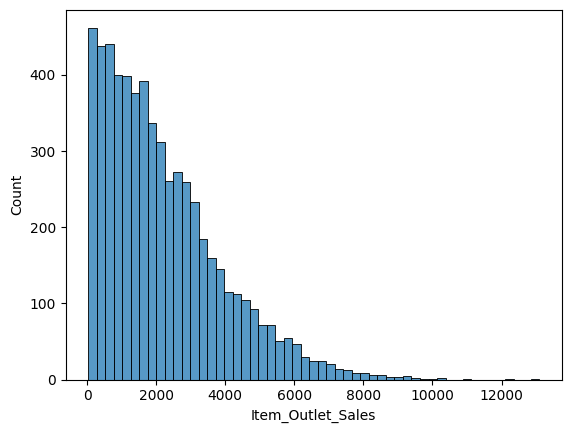

In [85]:
sns.histplot(y_train)

In [86]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
import xgboost as xgb
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_validate
import numpy as np

In [108]:
import numpy as np
from sklearn.model_selection import cross_validate
from pandas.api.types import is_numeric_dtype

def train_and_eval_model(model, x_train, y_train, cv=5):
  # Check NaNs for all columns
  print(f"NaNs in X before cross_validate: {x_train.isnull().sum().sum()}")

  # Check Infs only for numerical columns
  numerical_cols_names = [col for col in x_train.columns if is_numeric_dtype(x_train[col])]
  numerical_x_train = x_train[numerical_cols_names]

  print(f"Infs in X before cross_validate: {np.isinf(numerical_x_train).sum().sum()}")
  cv_results = cross_validate(model, x_train, y_train, cv=cv, scoring=('r2','neg_root_mean_squared_error'), error_score='raise')
  print('Model:', model)
  r2_scores= cv_results['test_r2']
  print('R2 CV scores:', r2_scores)
  print('Mean R2 Score:', np.mean(r2_scores),'/', np.std(r2_scores))

  rmse_scores= cv_results['test_neg_root_mean_squared_error']
  rmse_scores=[-1*score for score in rmse_scores]
  print('RMSE CV scores:', np.array(rmse_scores))
  print('Mean RMSE Score:', np.mean(rmse_scores),'/', np.std(rmse_scores))

In [90]:
rf= RandomForestRegressor(random_state=SEED)
train_and_eval_model(rf, x_train_final, y_train)

Model: RandomForestRegressor(random_state=42)
R2 CV scores: [0.56811404 0.52576698 0.54772476 0.55668662 0.52360183]
Mean R2 Score: 0.5443788471825595 / 0.01734428870400193
RMSE CV scores: [np.float64(1107.2678451235065), np.float64(1169.7657898004252), np.float64(1174.24284331175), np.float64(1151.2325100491357), np.float64(1197.7862674334915)]
Mean RMSE Score: 1160.0590511436617 / 30.277261584739314


In [97]:
gb= GradientBoostingRegressor(random_state=SEED)
train_and_eval_model(gb, x_train_final, y_train)

Model: GradientBoostingRegressor(random_state=42)
R2 CV scores: [0.6065274  0.59366925 0.57356358 0.60924345 0.55022613]
Mean R2 Score: 0.5866459646024772 / 0.022148578096336337
RMSE CV scores: [np.float64(1056.8793046591481), np.float64(1082.786581771003), np.float64(1140.2068860094903), np.float64(1080.838373141466), np.float64(1163.8349579736446)]
Mean RMSE Score: 1104.9092207109504 / 40.23395923794627


In [103]:
hgh= HistGradientBoostingRegressor(random_state=SEED)
train_and_eval_model(hgh, x_train_final, y_train)

NaNs in X before cross_validate: 0
Infs in X before cross_validate: 0
Model: HistGradientBoostingRegressor(random_state=42)
R2 CV scores: [0.58793884 0.54297938 0.54501125 0.585042   0.54567103]
Mean R2 Score: 0.5613284973532673 / 0.0205841656268121
RMSE CV scores: [np.float64(1081.5559461370956), np.float64(1148.3411312834949), np.float64(1177.760118083806), np.float64(1113.806369963145), np.float64(1169.713511250089)]
Mean RMSE Score: 1138.235415343526 / 35.957026103361265


In [100]:
xgr= xgb.XGBRegressor(random_state=SEED)
train_and_eval_model(xgr, x_train_final, y_train)

NaNs in X before cross_validate: 0
Infs in X before cross_validate: 0
Model: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)
R2 CV scores: [0.57730972 0.55914207 0.54421335 0.58393553 0.52431207]
Mean R2 Score: 0.5577825481764618 / 0.021778582707669483
RMSE CV scores: [np.float64(1095.416494682338

In [101]:
lgbr= LGBMRegressor(random_state=SEED)
train_and_eval_model(lgbr, x_train_final, y_train)

NaNs in X before cross_validate: 0
Infs in X before cross_validate: 0
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000827 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 802
[LightGBM] [Info] Number of data points in the train set: 4772, number of used features: 30
[LightGBM] [Info] Start training from score 2221.272740
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000446 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 807
[LightGBM] [Info] Number of data points in the train set: 4773, number of used features: 30
[LightGBM] [

# Handling Categorical Data
Expt 2: All categorical columns - Native Handling


In [104]:
x_train_copy = x_train_c.copy().drop(columns='Item_Identifier')
cat_cols= x_train_copy.select_dtypes(include=['object']).columns.tolist()
num_cols = x_train_copy.select_dtypes(exclude=['object']).columns.tolist()
cat_cols,num_cols

(['Item_Fat_Content',
  'Item_Type',
  'Outlet_Identifier',
  'Outlet_Size',
  'Outlet_Location_Type',
  'Outlet_Type'],
 ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year'])

In [105]:
x_train_copy[cat_cols]= x_train_copy[cat_cols].astype('category')
n_categorical_features= len(cat_cols)
n_numerical_features= len(num_cols)
x_train_copy=x_train_copy[cat_cols+num_cols]

x_train_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5966 entries, 1921 to 7270
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Item_Fat_Content           5966 non-null   category
 1   Item_Type                  5966 non-null   category
 2   Outlet_Identifier          5966 non-null   category
 3   Outlet_Size                5966 non-null   category
 4   Outlet_Location_Type       5966 non-null   category
 5   Outlet_Type                5966 non-null   category
 6   Item_Weight                5966 non-null   float64 
 7   Item_Visibility            5966 non-null   float64 
 8   Item_MRP                   5966 non-null   float64 
 9   Outlet_Establishment_Year  5966 non-null   int64   
dtypes: category(6), float64(3), int64(1)
memory usage: 269.1 KB


In [109]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.compose import make_column_selector

categorical_mask = [True] * n_categorical_features + [False] * n_numerical_features

ordinal_encoder = make_column_transformer(
    (
        OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=np.nan
        ),
        make_column_selector(dtype_include="category"),
    ),
    remainder="passthrough",
)

hgb = make_pipeline(
    ordinal_encoder,
    HistGradientBoostingRegressor(
        random_state=42,
        categorical_features=categorical_mask
    ),
)

train_and_eval_model(
    model=hgb,
    x_train=x_train_copy,
    y_train=y_train
)

NaNs in X before cross_validate: 0
Infs in X before cross_validate: 0
Model: Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ordinalencoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=nan),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7ee3eeee8b30>)])),
                ('histgradientboostingregressor',
                 HistGradientBoostingRegressor(categorical_features=[True, True,
                                                                     True, True,
                                                                     True, True,
                                                                     False,
                                                               

In [110]:
lgbr= LGBMRegressor(random_state=SEED)
train_and_eval_model(lgbr, x_train_copy, y_train)

NaNs in X before cross_validate: 0
Infs in X before cross_validate: 0
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000409 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 782
[LightGBM] [Info] Number of data points in the train set: 4772, number of used features: 10
[LightGBM] [Info] Start training from score 2221.272740
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000211 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 787
[LightGBM] [Info] Number of data points in the train set: 4773, number of used features: 10
[LightGBM] [Info] Start training from score 2213.452868
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000204 seconds.
You can set 

# Handling Categorical Data
Expt 3: No Item Identifier - one hot encoded
  

In [112]:
cat_feats = x_train.select_dtypes(include=['object']).drop(columns=['Item_Identifier'])

ohe = OneHotEncoder(handle_unknown='ignore')
ohe.fit(cat_feats)

ohe_feature_names = ohe.get_feature_names_out(input_features=cat_feats.columns)

In [113]:
num_feats_train = x_train.select_dtypes(exclude=['object']).reset_index(drop=True)

cat_feats_train = x_train.select_dtypes(include=['object']).drop(
    columns=['Item_Identifier']
)

X_train_cat_ohe = pd.DataFrame(
    ohe.transform(cat_feats_train).toarray(),
    columns=ohe_feature_names
)

X_train_final = pd.concat(
    [num_feats_train, X_train_cat_ohe],
    axis=1
)

In [115]:
gb= GradientBoostingRegressor(random_state=SEED)
train_and_eval_model(gb, x_train_final, y_train)

NaNs in X before cross_validate: 0
Infs in X before cross_validate: 0
Model: GradientBoostingRegressor(random_state=42)
R2 CV scores: [0.6065274  0.59366925 0.57356358 0.60924345 0.55022613]
Mean R2 Score: 0.5866459646024772 / 0.022148578096336337
RMSE CV scores: [1056.87930466 1082.78658177 1140.20688601 1080.83837314 1163.83495797]
Mean RMSE Score: 1104.9092207109504 / 40.23395923794627


In [116]:
hgb= HistGradientBoostingRegressor(random_state=SEED)
train_and_eval_model(hgb, x_train_final, y_train)

NaNs in X before cross_validate: 0
Infs in X before cross_validate: 0
Model: HistGradientBoostingRegressor(random_state=42)
R2 CV scores: [0.58793884 0.54297938 0.54501125 0.585042   0.54567103]
Mean R2 Score: 0.5613284973532673 / 0.0205841656268121
RMSE CV scores: [1081.55594614 1148.34113128 1177.76011808 1113.80636996 1169.71351125]
Mean RMSE Score: 1138.235415343526 / 35.957026103361265


In [117]:
xgr= xgb.XGBRegressor(random_state=SEED)
train_and_eval_model(xgr, x_train_final, y_train)

NaNs in X before cross_validate: 0
Infs in X before cross_validate: 0
Model: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)
R2 CV scores: [0.57730972 0.55914207 0.54421335 0.58393553 0.52431207]
Mean R2 Score: 0.5577825481764618 / 0.021778582707669483
RMSE CV scores: [1095.41649468 1127.85261187 

In [118]:
lgbr= LGBMRegressor(random_state=SEED)
train_and_eval_model(lgbr, x_train_final, y_train)

NaNs in X before cross_validate: 0
Infs in X before cross_validate: 0
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000535 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 802
[LightGBM] [Info] Number of data points in the train set: 4772, number of used features: 30
[LightGBM] [Info] Start training from score 2221.272740
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000447 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 807
[LightGBM] [Info] Number of data points in the train set: 4773, number of used features: 30
[LightGBM] [

# Handling Categorical Data
Expt 4 :  Item Identifier - feature hashed, rest categorical - one hot encoded

In [120]:
from sklearn.feature_extraction import FeatureHasher

hash_vector_size=50
fh= FeatureHasher(n_features=hash_vector_size, input_type='string')
hashed_df= pd.DataFrame(fh.fit_transform(x_train['Item_Identifier'].apply(lambda x: [x])).toarray(),
                        columns=['H'+str(i) for i in range(hash_vector_size)])
hashed_df.head()

,H0,H1,H2,H3,H4,H5,H6,H7,H8,H9,...,H40,H41,H42,H43,H44,H45,H46,H47,H48,H49
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [121]:
cat_feats = x_train.select_dtypes(include=['object']).drop(columns=['Item_Identifier'])
ohe = OneHotEncoder(handle_unknown='ignore')
ohe.fit(cat_feats)
ohe_feature_names = ohe.get_feature_names_out(input_features=cat_feats.columns)

In [122]:
num_feats_train=x_train.select_dtypes(exclude=['object']).reset_index(drop=True)
cat_feats_train=x_train.select_dtypes(include=['object']).drop(columns=['Item_Identifier'])
X_train_cat_ohe = pd.DataFrame(
    ohe.transform(cat_feats_train).toarray(),
    columns=ohe_feature_names
)
X_train_final = pd.concat(
    [num_feats_train, X_train_cat_ohe, hashed_df],
    axis=1
)
x_train_final.head()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Identifier_DRA12,Item_Identifier_DRA24,Item_Identifier_DRA59,Item_Identifier_DRB01,Item_Identifier_DRB13,Item_Identifier_DRB24,...,Outlet_Size_High,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 1,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Grocery Store,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,7.72,0.147904,116.6466,1998,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,19.75,0.014301,103.0332,1997,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,8.60,0.054221,129.1310,1985,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,19.35,0.118342,222.6088,2002,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,18.35,0.092150,184.8266,1987,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0


In [123]:
gb= GradientBoostingRegressor(random_state=SEED)
train_and_eval_model(gb, x_train_final, y_train)

NaNs in X before cross_validate: 0
Infs in X before cross_validate: 0
Model: GradientBoostingRegressor(random_state=42)
R2 CV scores: [0.6065274  0.59366925 0.57356358 0.60924345 0.55022613]
Mean R2 Score: 0.5866459646024772 / 0.022148578096336337
RMSE CV scores: [1056.87930466 1082.78658177 1140.20688601 1080.83837314 1163.83495797]
Mean RMSE Score: 1104.9092207109504 / 40.23395923794627


In [124]:
xgr= xgb.XGBRegressor(random_state=SEED)
train_and_eval_model(xgr, x_train_final, y_train)

NaNs in X before cross_validate: 0
Infs in X before cross_validate: 0
Model: XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)
R2 CV scores: [0.57730972 0.55914207 0.54421335 0.58393553 0.52431207]
Mean R2 Score: 0.5577825481764618 / 0.021778582707669483
RMSE CV scores: [1095.41649468 1127.85261187 

In [126]:
x_test.shape

(2557, 11)

In [127]:
hashed_test_df= pd.DataFrame(fh.transform(x_test['Item_Identifier'].apply(lambda x: [x])).toarray(),
                        columns=['H'+str(i) for i in range(hash_vector_size)])
num_feats_test=x_test.select_dtypes(exclude=['object']).reset_index(drop=True)
cat_feats_test=x_test.select_dtypes(include=['object']).drop(columns=['Item_Identifier'])
X_test_cat_ohe = pd.DataFrame(
    ohe.transform(cat_feats_test).toarray(),
    columns=ohe_feature_names
)
X_test_final = pd.concat(
    [num_feats_test, X_test_cat_ohe, hashed_test_df],
    axis=1
)
X_test_final.head()


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Fat_Content_LF,Item_Fat_Content_Low Fat,Item_Fat_Content_Regular,Item_Fat_Content_low fat,Item_Fat_Content_reg,Item_Type_Baking Goods,...,H40,H41,H42,H43,H44,H45,H46,H47,H48,H49
0,14.300,0.026300,79.4302,1987,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,7.930,0.071136,42.7086,1997,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,14.500,0.041313,42.0454,1999,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,13.000,0.044767,173.7054,1985,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,10.195,0.012456,197.5110,2004,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [128]:
x_test_final.shape

(2557, 1573)

In [129]:
xgr= xgb.XGBRegressor(objective= 'reg:squarederror',random_state=SEED)
xgr.fit(x_train_final, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [131]:
y_pred = xgr.predict(x_test_final)

In [132]:
from sklearn.metrics import r2_score, mean_squared_error

In [136]:
print('R2 Score:', r2_score(y_test, y_pred))
print('RMSE Score:', np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.5701327508635561
RMSE Score: 1097.2945741485482


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

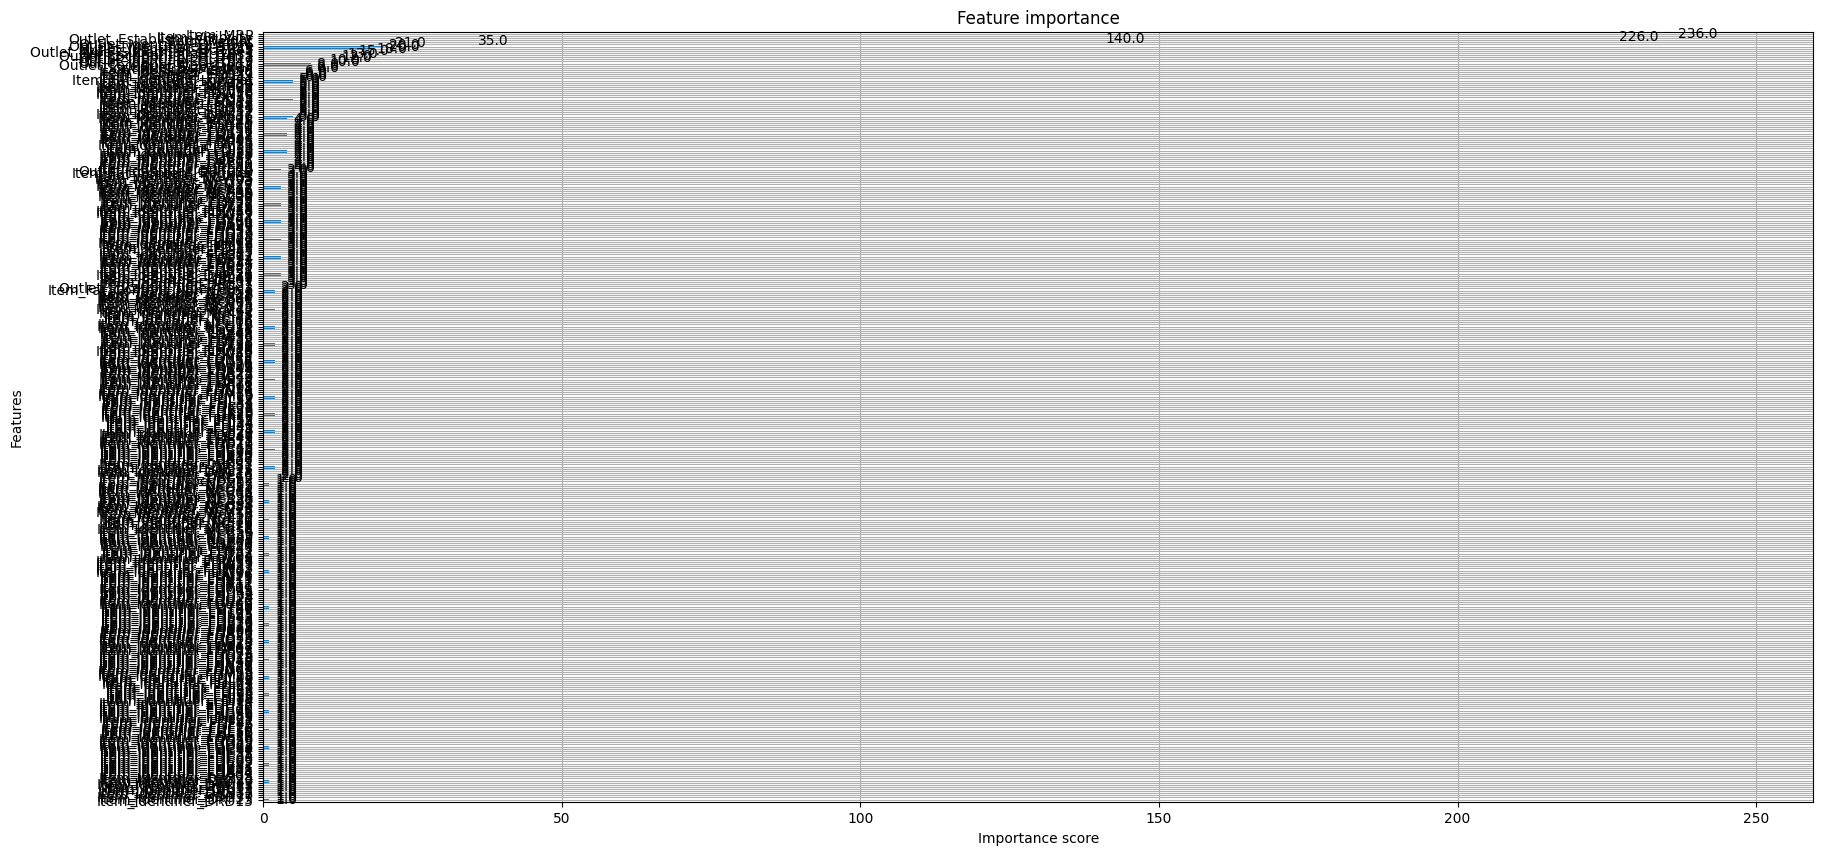

In [137]:
from xgboost import plot_importance
flg, ax = plt.subplots(1,1, figsize=(20,10))
plot_importance(xgr, ax=ax)

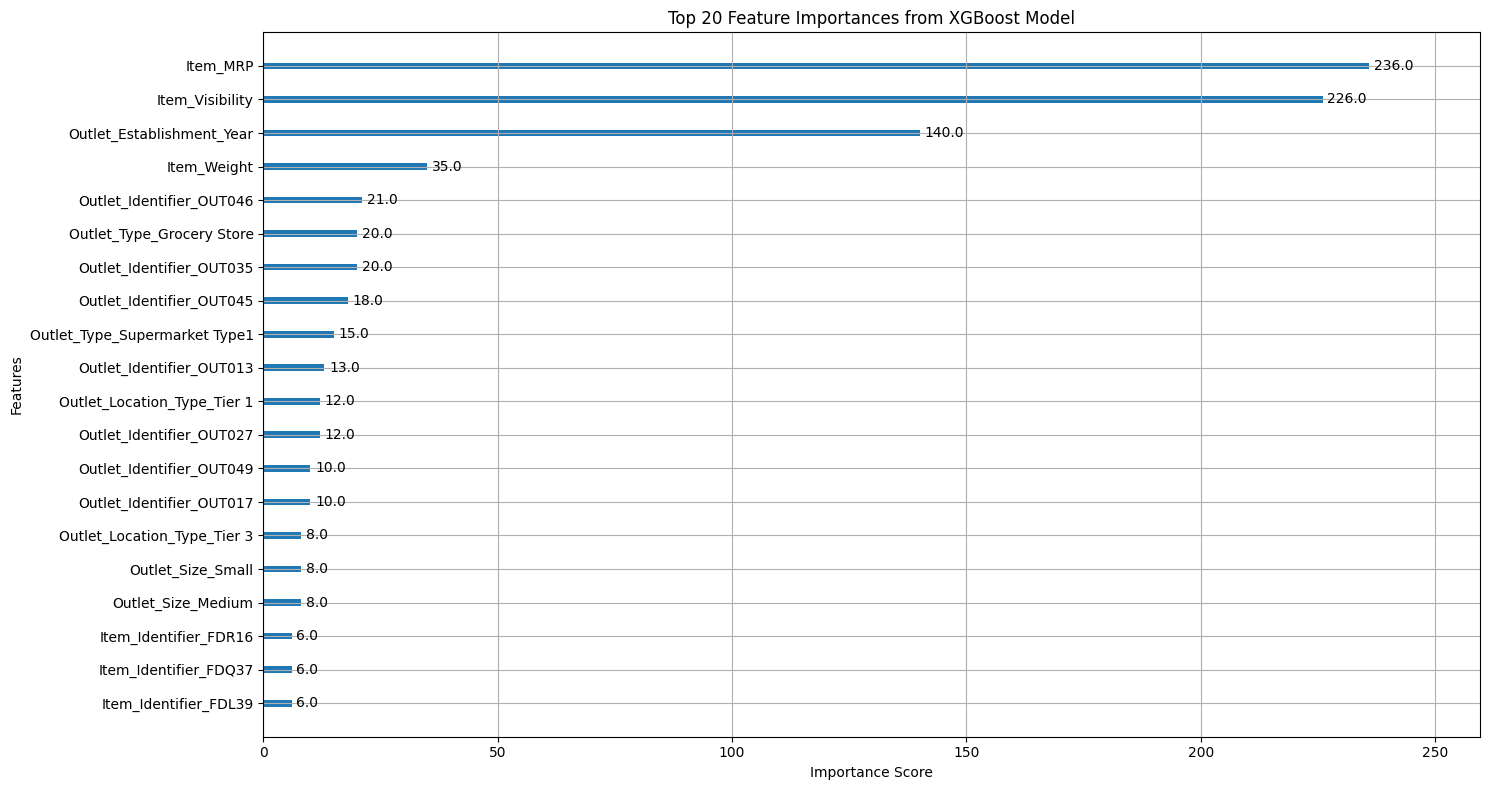

In [138]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Set a larger figure size for better readability
fig, ax = plt.subplots(figsize=(15, 8))

# Plot only the top 20 features
plot_importance(xgr, ax=ax, max_num_features=20)

plt.title('Top 20 Feature Importances from XGBoost Model')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

# New Section